# M2.6 — Phân tích mối quan hệ giữa feature và target

## Mục tiêu

Sau M2.4 và M2.5, các feature chính đã được hiểu tương đối rõ về distribution, cardinality, missingness và semantic đặc biệt. <br>

M2.6 chuyển sang câu hỏi: <br>
`Target Is Fraud? thay đổi như thế nào giữa các nhóm giá trị của feature?` <br>

Các nhóm feature được khảo sát gồm: <br>
- `Amount`; <br>
- `Use Chip`; <br>
- `MCC`; <br>
- các feature dẫn xuất từ thời gian; <br>
- location và location missingness. <br>

## Nguyên tắc bắt buộc

Mỗi phân tích categorical phải xem đồng thời: <br>
`transaction_count` <br>
`fraud_count` <br>
`fraud_rate` <br>

Không được kết luận một category có rủi ro cao chỉ vì fraud rate cao khi support rất nhỏ. <br>

`Lift` so với fraud rate toàn dataset chỉ được dùng như đại lượng mô tả tương đối, không phải bằng chứng nhân quả. <br>

## Ảnh hưởng từ các finding trước

M2.3 đã xác nhận target distribution thay đổi mạnh theo thời gian. <br>

Do đó một quan hệ feature ↔ target trên toàn dataset chưa chắc ổn định qua các temporal regime. <br>

M2.6 sẽ bổ sung một kiểm tra độ ổn định theo các giai đoạn quan trọng đã phát hiện ở M2.3. <br>

M2.5 đã xác nhận location missing có quan hệ cấu trúc rất mạnh với transaction mode. <br>

Do đó missing location ↔ fraud phải được xem cùng `Use Chip`, không được diễn giải missing như một fraud signal độc lập. <br>

## Ranh giới

Trong M2.6: <br>
- chưa lựa chọn final feature set; <br>
- chưa encoding; <br>
- chưa feature selection bằng model; <br>
- chưa huấn luyện classifier; <br>
- chưa đưa ra causal claim; <br>
- chưa dùng raw `User`, `Card`, `Merchant Name` làm candidate feature; <br>
- không sử dụng `Errors?` trong Model V1. <br>

`Mục tiêu của M2.6 là phát hiện và mô tả association, không chứng minh causation.`

## Thiết lập môi trường thực thi

Notebook này được thiết kế để `chạy độc lập`. <br>

Phần lớn thống kê feature-target được thu thập trong một lần full scan. <br>

Đối với Amount dương, M2.6 còn tạo các nhóm quantile từ một sample target-blind 1% và thực hiện một lần đọc bổ sung để kiểm tra fraud rate theo magnitude. <br>

Các quantile này chỉ phục vụ EDA. <br>
Nếu sau này sử dụng binning trong model, bin boundary phải được học từ training data thay vì sao chép trực tiếp từ full-dataset EDA. <br>

In [1]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# Xác định thư mục gốc project
# ============================================================

DATA_RELATIVE_PATH = (
    Path("data")
    / "raw"
    / "ibm_tabformer"
    / "card_transaction.v1.csv"
)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = None

for candidate in candidate_roots:
    candidate = candidate.resolve()

    if (
        candidate
        / DATA_RELATIVE_PATH
    ).exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Không xác định được PROJECT_ROOT. "
        "Không tìm thấy file dữ liệu."
    )


DATA_PATH = (
    PROJECT_ROOT
    / DATA_RELATIVE_PATH
)


# ============================================================
# Cấu hình M2.6
# ============================================================

TARGET_COLUMN = "Is Fraud?"

CHUNK_SIZE = 500_000

RANDOM_STATE = 42

AMOUNT_SAMPLE_FRAC = 0.01

CATEGORY_PREVIEW_N = 15


print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nDATA_PATH:")
print(DATA_PATH)

print("\nFile tồn tại:")
print(DATA_PATH.exists())

PROJECT_ROOT:
/Users/minhtoan/SE/HocTrenLop/Trí tuệ nhân tạo/fraud-risk-screening

DATA_PATH:
/Users/minhtoan/SE/HocTrenLop/Trí tuệ nhân tạo/fraud-risk-screening/data/raw/ibm_tabformer/card_transaction.v1.csv

File tồn tại:
True


### Nhận xét thiết lập môi trường

Notebook đã xác định được đúng `PROJECT_ROOT` và đường dẫn tới raw artifact. <br>

Kết quả `File tồn tại: True` xác nhận M2.6 có thể chạy độc lập, không phụ thuộc vào kernel hoặc các biến đã được tạo ở những notebook M2 trước. <br>

M2.6 sử dụng `CHUNK_SIZE = 500,000` để tổng hợp feature-target trên toàn bộ dataset và lấy sample Amount dương phục vụ việc xây các quantile bin. <br>

`Kết luận: PASS`

## M2.6.1 — Quét toàn bộ dataset và tổng hợp feature-target

### Câu hỏi

Có thể thu thập các thống kê cần thiết cho phần lớn M2.6 chỉ trong một full scan hay không? <br>

### Phương pháp

Chỉ đọc các cột cần thiết: <br>
`Year` <br>
`Month` <br>
`Day` <br>
`Time` <br>
`Amount` <br>
`Use Chip` <br>
`MCC` <br>
`Merchant City` <br>
`Merchant State` <br>
`Zip` <br>
`Is Fraud?` <br>

Trong một lần quét, thu thập count và fraud count cho: <br>
- Use Chip; <br>
- Amount sign; <br>
- Amount sign × Use Chip; <br>
- MCC; <br>
- hour_of_day; <br>
- day_of_week; <br>
- month; <br>
- Merchant City / State / Zip; <br>
- semantic location status; <br>
- location status × Use Chip; <br>
- một số temporal period quan trọng từ M2.3. <br>

Đồng thời lấy sample 1% Amount dương để xây quantile bin ở phần sau. <br>

In [2]:
M26_USECOLS = [
    "Year",
    "Month",
    "Day",
    "Time",
    "Amount",
    "Use Chip",
    "MCC",
    "Merchant City",
    "Merchant State",
    "Zip",
    TARGET_COLUMN,
]


def parse_amount(amount_series):
    cleaned = (
        amount_series
        .astype("string")
        .str.replace(
            "$",
            "",
            regex=False,
        )
        .str.replace(
            ",",
            "",
            regex=False,
        )
        .str.strip()
    )

    return pd.to_numeric(
        cleaned,
        errors="coerce",
    )


def update_single_group(
    total_counter,
    fraud_counter,
    values,
    fraud_mask,
):
    total_counter.update(
        values
        .value_counts(
            dropna=False
        )
        .to_dict()
    )

    fraud_counter.update(
        values.loc[
            fraud_mask
        ]
        .value_counts(
            dropna=False
        )
        .to_dict()
    )


def update_multi_group(
    total_counter,
    fraud_counter,
    group_df,
    fraud_mask,
):
    total_counts = (
        group_df
        .value_counts(
            dropna=False
        )
    )

    fraud_counts = (
        group_df.loc[
            fraud_mask
        ]
        .value_counts(
            dropna=False
        )
    )

    total_counter.update(
        {
            (
                key
                if isinstance(
                    key,
                    tuple,
                )
                else (key,)
            ):
                int(value)

            for key, value
            in total_counts.items()
        }
    )

    fraud_counter.update(
        {
            (
                key
                if isinstance(
                    key,
                    tuple,
                )
                else (key,)
            ):
                int(value)

            for key, value
            in fraud_counts.items()
        }
    )

In [3]:
total_rows = 0
total_fraud = 0
missing_target_count = 0


# Use Chip
use_chip_total = Counter()
use_chip_fraud = Counter()


# Amount sign
amount_sign_total = Counter()
amount_sign_fraud = Counter()

amount_sign_mode_total = Counter()
amount_sign_mode_fraud = Counter()


# MCC
mcc_total = Counter()
mcc_fraud = Counter()


# Time
hour_total = Counter()
hour_fraud = Counter()

day_of_week_total = Counter()
day_of_week_fraud = Counter()

month_total = Counter()
month_fraud = Counter()


# Location raw categories
city_total = Counter()
city_fraud = Counter()

state_total = Counter()
state_fraud = Counter()

zip_total = Counter()
zip_fraud = Counter()


# Semantic location
location_status_total = Counter()
location_status_fraud = Counter()

location_mode_total = Counter()
location_mode_fraud = Counter()


# Temporal stability
period_use_chip_total = Counter()
period_use_chip_fraud = Counter()

period_amount_mode_total = Counter()
period_amount_mode_fraud = Counter()


# Amount sample
positive_amount_sample_parts = []

In [4]:
for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_PATH,
        usecols=M26_USECOLS,
        chunksize=CHUNK_SIZE,
        dtype={
            TARGET_COLUMN: "string",
        },
    ),
    start=1,
):
    total_rows += len(chunk)

    # --------------------------------------------------------
    # Target
    # --------------------------------------------------------

    target = (
        chunk[TARGET_COLUMN]
        .astype("string")
        .str.strip()
    )

    target = target.mask(
        target.eq("")
    )

    missing_target_count += int(
        target.isna().sum()
    )

    fraud_mask = (
        target.eq("Yes")
        .fillna(False)
    )

    total_fraud += int(
        fraud_mask.sum()
    )

    # --------------------------------------------------------
    # Amount
    # --------------------------------------------------------

    amount_numeric = parse_amount(
        chunk["Amount"]
    )

    amount_sign = pd.Series(
        np.select(
            [
                amount_numeric < 0,
                amount_numeric == 0,
                amount_numeric > 0,
            ],
            [
                "negative",
                "zero",
                "positive",
            ],
            default="missing_or_invalid",
        ),
        index=chunk.index,
        dtype="string",
    )

    update_single_group(
        amount_sign_total,
        amount_sign_fraud,
        amount_sign,
        fraud_mask,
    )

    amount_mode_df = pd.DataFrame(
        {
            "Use Chip":
                chunk[
                    "Use Chip"
                ].astype("string"),

            "amount_sign":
                amount_sign,
        },
        index=chunk.index,
    )

    update_multi_group(
        amount_sign_mode_total,
        amount_sign_mode_fraud,
        amount_mode_df,
        fraud_mask,
    )

    # Sample target-blind Amount dương
    positive_amount = (
        amount_numeric[
            amount_numeric > 0
        ]
    )

    if not positive_amount.empty:
        positive_amount_sample_parts.append(
            positive_amount.sample(
                frac=AMOUNT_SAMPLE_FRAC,
                random_state=(
                    RANDOM_STATE
                    + chunk_number
                ),
            )
        )

    # --------------------------------------------------------
    # Use Chip
    # --------------------------------------------------------

    use_chip = (
        chunk["Use Chip"]
        .astype("string")
    )

    update_single_group(
        use_chip_total,
        use_chip_fraud,
        use_chip,
        fraud_mask,
    )

    # --------------------------------------------------------
    # MCC
    # --------------------------------------------------------

    update_single_group(
        mcc_total,
        mcc_fraud,
        chunk["MCC"],
        fraud_mask,
    )

    # --------------------------------------------------------
    # Time
    # --------------------------------------------------------

    hour = pd.to_numeric(
        chunk["Time"]
        .astype("string")
        .str.slice(0, 2),
        errors="coerce",
    ).astype("Int64")

    update_single_group(
        hour_total,
        hour_fraud,
        hour,
        fraud_mask,
    )


    transaction_date = pd.to_datetime(
        {
            "year":
                chunk["Year"],

            "month":
                chunk["Month"],

            "day":
                chunk["Day"],
        },
        errors="coerce",
    )

    day_of_week = (
        transaction_date
        .dt.dayofweek
        .astype("Int64")
    )

    update_single_group(
        day_of_week_total,
        day_of_week_fraud,
        day_of_week,
        fraud_mask,
    )


    update_single_group(
        month_total,
        month_fraud,
        chunk["Month"],
        fraud_mask,
    )

    # --------------------------------------------------------
    # Location labels
    # --------------------------------------------------------

    city_label = (
        chunk["Merchant City"]
        .astype("string")
        .fillna("<MISSING>")
    )

    state_label = (
        chunk["Merchant State"]
        .astype("string")
        .fillna("<MISSING>")
    )

    zip_label = (
        chunk["Zip"]
        .astype("Int64")
        .astype("string")
        .fillna("<MISSING>")
    )


    update_single_group(
        city_total,
        city_fraud,
        city_label,
        fraud_mask,
    )

    update_single_group(
        state_total,
        state_fraud,
        state_label,
        fraud_mask,
    )

    update_single_group(
        zip_total,
        zip_fraud,
        zip_label,
        fraud_mask,
    )

    # --------------------------------------------------------
    # Semantic location status
    # --------------------------------------------------------

    city_online = (
        city_label
        .str.strip()
        .str.upper()
        .eq("ONLINE")
        .fillna(False)
    )

    state_missing = (
        chunk[
            "Merchant State"
        ]
        .isna()
    )

    zip_missing = (
        chunk["Zip"]
        .isna()
    )


    location_status = pd.Series(
        np.select(
            [
                (
                    city_online
                    & state_missing
                    & zip_missing
                ),

                (
                    (~state_missing)
                    & zip_missing
                ),

                (
                    state_missing
                    & (~zip_missing)
                ),

                (
                    state_missing
                    & zip_missing
                ),
            ],
            [
                "CITY_ONLINE_STATE_ZIP_MISSING",
                "STATE_PRESENT_ZIP_MISSING",
                "STATE_MISSING_ZIP_PRESENT",
                "STATE_ZIP_MISSING_OTHER_CITY",
            ],
            default="STATE_ZIP_PRESENT",
        ),
        index=chunk.index,
        dtype="string",
    )


    update_single_group(
        location_status_total,
        location_status_fraud,
        location_status,
        fraud_mask,
    )


    location_mode_df = pd.DataFrame(
        {
            "Use Chip":
                use_chip,

            "location_status":
                location_status,
        },
        index=chunk.index,
    )


    update_multi_group(
        location_mode_total,
        location_mode_fraud,
        location_mode_df,
        fraud_mask,
    )

    # --------------------------------------------------------
    # Giai đoạn thời gian quan trọng từ M2.3
    # --------------------------------------------------------

    year = chunk["Year"]
    month = chunk["Month"]


    analysis_period = pd.Series(
        np.select(
            [
                year.eq(2018),

                (
                    year.eq(2019)
                    & month.between(
                        1,
                        10,
                    )
                ),

                (
                    year.eq(2019)
                    & month.between(
                        11,
                        12,
                    )
                ),

                (
                    year.eq(2020)
                    & month.between(
                        1,
                        2,
                    )
                ),
            ],
            [
                "2018",
                "2019-01_to_10",
                "2019-11_to_12",
                "2020-01_to_02",
            ],
            default="OTHER",
        ),
        index=chunk.index,
        dtype="string",
    )


    recent_mask = (
        analysis_period
        .ne("OTHER")
    )


    period_use_chip_df = pd.DataFrame(
        {
            "period":
                analysis_period[
                    recent_mask
                ],

            "Use Chip":
                use_chip[
                    recent_mask
                ],
        }
    )


    update_multi_group(
        period_use_chip_total,
        period_use_chip_fraud,
        period_use_chip_df,
        fraud_mask.loc[
            recent_mask
        ],
    )


    period_amount_mode_df = pd.DataFrame(
        {
            "period":
                analysis_period[
                    recent_mask
                ],

            "Use Chip":
                use_chip[
                    recent_mask
                ],

            "amount_sign":
                amount_sign[
                    recent_mask
                ],
        }
    )


    update_multi_group(
        period_amount_mode_total,
        period_amount_mode_fraud,
        period_amount_mode_df,
        fraud_mask.loc[
            recent_mask
        ],
    )

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    if (
        chunk_number % 10 == 0
        or len(chunk) < CHUNK_SIZE
    ):
        print(
            f"Đã xử lý {chunk_number} chunk "
            f"- tổng số dòng: {total_rows:,}"
        )


positive_amount_sample = pd.concat(
    positive_amount_sample_parts,
    ignore_index=True,
)


print("\nHoàn tất full scan M2.6.")

print(
    "Tổng số dòng:",
    f"{total_rows:,}",
)

print(
    "Tổng fraud:",
    f"{total_fraud:,}",
)

print(
    "Target missing:",
    missing_target_count,
)

print(
    "Positive Amount sample:",
    f"{len(positive_amount_sample):,}",
)

Đã xử lý 10 chunk - tổng số dòng: 5,000,000
Đã xử lý 20 chunk - tổng số dòng: 10,000,000
Đã xử lý 30 chunk - tổng số dòng: 15,000,000
Đã xử lý 40 chunk - tổng số dòng: 20,000,000
Đã xử lý 49 chunk - tổng số dòng: 24,386,900

Hoàn tất full scan M2.6.
Tổng số dòng: 24,386,900
Tổng fraud: 29,757
Target missing: 0
Positive Amount sample: 231,220


### Nhận xét M2.6.1

Toàn bộ dataset đã được quét thành công qua `49 chunk`, với tổng cộng `24,386,900 transaction`. <br>

Tổng số fraud thu được là `29,757` và không có target missing. <br>

Hai con số này khớp với target audit ở các bước trước. <br>

Sample Amount dương có `231,220 giá trị`, xấp xỉ 1% tổng số Amount dương và phù hợp với thiết kế của notebook. <br>

Trong một full scan, notebook đã thu thập được các thống kê cần thiết cho Use Chip, Amount sign, MCC, các feature thời gian, location và một số temporal period quan trọng. <br>

Do đó các relationship chính trong M2.6 được xây từ toàn bộ population thay vì từ một sample, ngoại trừ boundary của Amount quantile được ước lượng từ sample target-blind 1%. <br>

`Kết luận: PASS`

## Helper tạo bảng relationship

Ta sẽ dùng chung một quy tắc cho mọi feature:

support
+
fraud count
+
fraud rate
+
lift
+
tỷ trọng fraud

In [5]:
overall_fraud_rate_pct = (
    total_fraud
    / total_rows
    * 100
)


def build_relationship_df(
    total_counter,
    fraud_counter,
    feature_name,
):
    rows = []

    for value, transaction_count in (
        total_counter.items()
    ):
        fraud_count = int(
            fraud_counter.get(
                value,
                0,
            )
        )

        fraud_rate_pct = (
            fraud_count
            / transaction_count
            * 100
        )

        rows.append(
            {
                feature_name:
                    value,

                "transaction_count":
                    int(
                        transaction_count
                    ),

                "fraud_count":
                    fraud_count,

                "fraud_rate_pct":
                    fraud_rate_pct,

                "lift_vs_overall":
                    (
                        fraud_rate_pct
                        / overall_fraud_rate_pct
                    ),

                "fraud_share_pct":
                    (
                        fraud_count
                        / total_fraud
                        * 100
                    ),
            }
        )

    return pd.DataFrame(
        rows
    )


def build_multi_relationship_df(
    total_counter,
    fraud_counter,
    column_names,
):
    rows = []

    for key, transaction_count in (
        total_counter.items()
    ):
        fraud_count = int(
            fraud_counter.get(
                key,
                0,
            )
        )

        fraud_rate_pct = (
            fraud_count
            / transaction_count
            * 100
        )

        row = {
            column:
                value

            for column, value
            in zip(
                column_names,
                key,
            )
        }

        row.update(
            {
                "transaction_count":
                    int(
                        transaction_count
                    ),

                "fraud_count":
                    fraud_count,

                "fraud_rate_pct":
                    fraud_rate_pct,

                "lift_vs_overall":
                    (
                        fraud_rate_pct
                        / overall_fraud_rate_pct
                    ),

                "fraud_share_pct":
                    (
                        fraud_count
                        / total_fraud
                        * 100
                    ),
            }
        )

        rows.append(
            row
        )

    return pd.DataFrame(
        rows
    )


print(
    "Fraud rate toàn dataset (%):",
    overall_fraud_rate_pct,
)

Fraud rate toàn dataset (%): 0.12202042900081601


## M2.6.2 — Quan hệ giữa Use Chip và target

### Câu hỏi

Fraud rate có giống nhau giữa `Swipe`, `Chip` và `Online Transaction` hay không? <br>

Nếu khác nhau, chênh lệch đó lớn đến mức nào và mỗi nhóm có support bao nhiêu? <br>

### Phương pháp

Với từng transaction mode, hiển thị đồng thời: <br>
`transaction_count` <br>
`fraud_count` <br>
`fraud_rate_pct` <br>
`lift_vs_overall` <br>
`fraud_share_pct` <br>

Không diễn giải khác biệt này như quan hệ nhân quả. <br>

In [6]:
use_chip_target_df = (
    build_relationship_df(
        use_chip_total,
        use_chip_fraud,
        "Use Chip",
    )
    .sort_values(
        "transaction_count",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    use_chip_target_df
)

,Use Chip,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,Swipe Transaction,15386082,6572,0.042714,0.350056,22.085560
1,Chip Transaction,6287598,4836,0.076913,0.630331,16.251638
2,Online Transaction,2713220,18349,0.676281,5.542361,61.662802


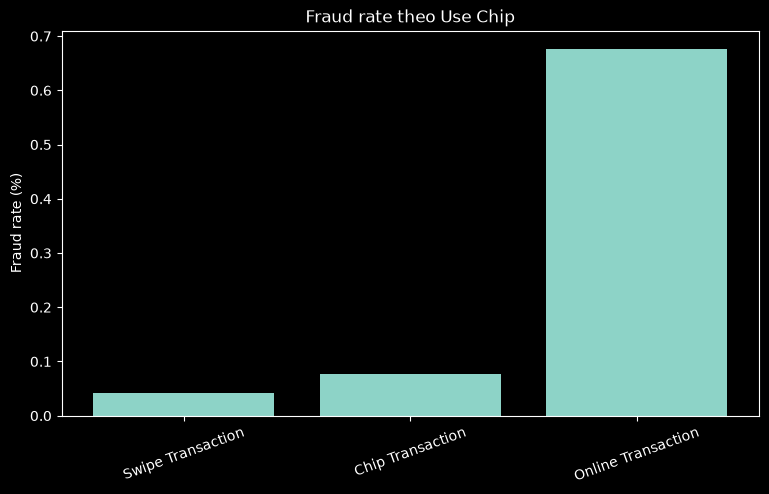

In [7]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    use_chip_target_df[
        "Use Chip"
    ],
    use_chip_target_df[
        "fraud_rate_pct"
    ],
)

plt.ylabel(
    "Fraud rate (%)"
)

plt.title(
    "Fraud rate theo Use Chip"
)

plt.xticks(
    rotation=20,
)

plt.show()

### Nhận xét M2.6.2

Trên toàn bộ dataset, fraud rate khác nhau rõ rệt giữa ba transaction mode. <br>

`Swipe Transaction` <br>
→ `15,386,082 transaction` <br>
→ `6,572 fraud` <br>
→ `fraud rate ≈ 0.0427%` <br>
→ `lift ≈ 0.35×` mức toàn dataset. <br>

`Chip Transaction` <br>
→ `6,287,598 transaction` <br>
→ `4,836 fraud` <br>
→ `fraud rate ≈ 0.0769%` <br>
→ `lift ≈ 0.63×`. <br>

`Online Transaction` <br>
→ `2,713,220 transaction` <br>
→ `18,349 fraud` <br>
→ `fraud rate ≈ 0.6763%` <br>
→ `lift ≈ 5.54×`. <br>

Mặc dù Online Transaction chỉ chiếm khoảng 11% tổng transaction, nhóm này chứa khoảng `61.66% toàn bộ fraud`. <br>

Nếu chỉ nhìn aggregation toàn lịch sử, Online Transaction có association với fraud mạnh hơn đáng kể so với Swipe và Chip. <br>

Tuy nhiên M2.3 đã chứng minh fraud distribution thay đổi mạnh theo thời gian. <br>

Do đó kết quả trên chưa đủ để kết luận rằng association `Online ↔ fraud` ổn định hoặc sẽ tồn tại ở future data. <br>

Độ ổn định của relationship này được kiểm tra tiếp ở M2.6.8. <br>

`Kết luận tạm thời: Use Chip có association mạnh với target trên full dataset, đặc biệt ở Online Transaction, nhưng cần kiểm tra temporal stability trước khi coi đây là tín hiệu ổn định.`

## M2.6.3 — Quan hệ Amount sign, transaction mode và target

### Câu hỏi

Fraud rate khác nhau như thế nào giữa Amount âm / zero / dương? <br>

Quan hệ này có giống nhau trong Swipe, Chip và Online Transaction hay không? <br>

### Phương pháp

Phân tích hai cấp: <br>
`Amount sign ↔ target` <br>
và <br>
`Amount sign × Use Chip ↔ target` <br>

Việc stratify theo Use Chip là cần thiết vì M2.5 đã cho thấy distribution của Amount sign thay đổi mạnh theo transaction mode. <br>

In [8]:
amount_sign_target_df = (
    build_relationship_df(
        amount_sign_total,
        amount_sign_fraud,
        "amount_sign",
    )
    .sort_values(
        "transaction_count",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    amount_sign_target_df
)

,amount_sign,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,positive,23122004,28619,0.123774,1.014370,96.175690
1,negative,1244683,1125,0.090384,0.740732,3.780623
2,zero,20213,13,0.064315,0.527084,0.043687


In [9]:
amount_sign_mode_target_df = (
    build_multi_relationship_df(
        amount_sign_mode_total,
        amount_sign_mode_fraud,
        [
            "Use Chip",
            "amount_sign",
        ],
    )
    .sort_values(
        [
            "Use Chip",
            "amount_sign",
        ]
    )
    .reset_index(drop=True)
)


display(
    amount_sign_mode_target_df
)

,Use Chip,amount_sign,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,Chip Transaction,negative,342120,83,0.024260,0.198823,0.278926
1,Chip Transaction,positive,5939649,4747,0.079921,0.654977,15.952549
2,Chip Transaction,zero,5829,6,0.102934,0.843577,0.020163
3,Online Transaction,negative,13499,896,6.637529,54.396864,3.011056
4,Online Transaction,positive,2699712,17447,0.646254,5.296278,58.631582
5,Online Transaction,zero,9,6,66.666667,546.356600,0.020163
6,Swipe Transaction,negative,889064,146,0.016422,0.134582,0.490641
7,Swipe Transaction,positive,14482643,6425,0.044363,0.363574,21.591558
8,Swipe Transaction,zero,14375,1,0.006957,0.057011,0.003361


### Nhận xét M2.6.3

Khi chỉ xét `Amount sign` trên toàn dataset, khác biệt fraud rate không quá lớn theo hướng Amount âm nguy hiểm hơn. <br>

`Positive Amount` <br>
→ `23,122,004 transaction` <br>
→ `28,619 fraud` <br>
→ `fraud rate ≈ 0.1238%` <br>
→ gần mức fraud rate chung. <br>

`Negative Amount` <br>
→ `1,244,683 transaction` <br>
→ `1,125 fraud` <br>
→ `fraud rate ≈ 0.0904%` <br>
→ thấp hơn mức chung. <br>

`Zero Amount` <br>
→ `20,213 transaction` <br>
→ `13 fraud` <br>
→ `fraud rate ≈ 0.0643%`. <br>

Như vậy `negative Amount` tự nó không phải nhóm có fraud rate cao hơn toàn dataset. <br>

Tuy nhiên khi kết hợp với `Use Chip`, cấu trúc thay đổi rất mạnh. <br>

Đáng chú ý nhất là: <br>
`Negative + Online Transaction` <br>
→ `13,499 transaction` <br>
→ `896 fraud` <br>
→ `fraud rate ≈ 6.64%` <br>
→ `lift ≈ 54.4×`. <br>

Trong khi đó: <br>
`Negative + Chip` có fraud rate chỉ khoảng `0.0243%`; <br>
`Negative + Swipe` chỉ khoảng `0.0164%`. <br>

Như vậy association của negative Amount phụ thuộc rất mạnh vào transaction mode. <br>

Một output cực đoan khác là: <br>
`Zero + Online = 6 fraud / 9 transaction = 66.67%`. <br>

Tuy nhiên support chỉ có `9 transaction`, nên đây chính là ví dụ cho thấy fraud rate cực cao không đủ để tạo kết luận đáng tin khi mẫu quá nhỏ. <br>

Không nên sử dụng nhóm Zero + Online như một finding mạnh hoặc rule dự đoán. <br>

Đối với Online Transaction nói chung, ngay cả Positive Amount cũng có fraud rate khoảng `0.646%`, cao hơn mức toàn dataset khoảng `5.30×`. <br>

Vì vậy phần association cực mạnh của Negative + Online có thể phản ánh cả interaction giữa sign và transaction mode, chứ không thể quy riêng cho negative Amount. <br>

`Kết luận: Amount sign có association tương đối yếu khi xét đơn lẻ nhưng xuất hiện interaction rất mạnh với transaction mode. Negative + Online là finding nổi bật trên full dataset, nhưng support và temporal stability phải được xem trước khi diễn giải hoặc sử dụng cho modeling.`

## M2.6.4 — Quan hệ giữa magnitude của Amount dương và target

### Vì sao kiểm tra này tồn tại?

M2.4 cho thấy Amount có distribution lệch mạnh và tail dài. <br>

Nếu tự đặt các khoảng tiền cố định, kết quả dễ phụ thuộc vào threshold chủ quan. <br>

Do đó M2.6 chia `Amount > 0` thành các nhóm quantile có support gần tương đương. <br>

### Phương pháp

Từ sample target-blind 1% của Amount dương: <br>
- tính 10 quantile bin; <br>
- dùng các boundary đó để đọc lại toàn dataset; <br>
- tính transaction count, fraud count và fraud rate trong từng bin. <br>

`10 bin` chỉ là độ phân giải mô tả cho EDA, không phải quyết định preprocessing hoặc feature engineering. <br>

In [10]:
positive_amount_deciles = (
    positive_amount_sample
    .quantile(
        np.linspace(
            0,
            1,
            11,
        )
    )
)


amount_bin_edges = (
    positive_amount_deciles
    .to_numpy(
        dtype="float64"
    )
)


# Bao phủ toàn bộ Amount dương
amount_bin_edges[0] = 0.0
amount_bin_edges[-1] = np.inf


# Phòng trường hợp quantile trùng nhau
amount_bin_edges = np.unique(
    amount_bin_edges
)


amount_bin_labels = [
    f"Q{i + 1}"
    for i in range(
        len(amount_bin_edges)
        - 1
    )
]


amount_bin_definition_df = pd.DataFrame(
    {
        "amount_bin":
            amount_bin_labels,

        "lower_bound":
            amount_bin_edges[:-1],

        "upper_bound":
            amount_bin_edges[1:],
    }
)


display(
    amount_bin_definition_df
)

,amount_bin,lower_bound,upper_bound
0,Q1,0.000,3.240
1,Q2,3.240,8.680
2,Q3,8.680,14.530
3,Q4,14.530,22.680
4,Q5,22.680,33.260
5,Q6,33.260,44.770
6,Q7,44.770,59.740
7,Q8,59.740,79.812
8,Q9,79.812,109.450
9,Q10,109.450,inf


In [11]:
amount_bin_total = Counter()
amount_bin_fraud = Counter()


for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_PATH,
        usecols=[
            "Amount",
            TARGET_COLUMN,
        ],
        chunksize=CHUNK_SIZE,
        dtype={
            TARGET_COLUMN: "string",
        },
    ),
    start=1,
):
    amount_numeric = parse_amount(
        chunk["Amount"]
    )

    target = (
        chunk[TARGET_COLUMN]
        .astype("string")
        .str.strip()
    )

    fraud_mask = (
        target.eq("Yes")
        .fillna(False)
    )

    positive_mask = (
        amount_numeric > 0
    )


    amount_bin = pd.cut(
        amount_numeric.loc[
            positive_mask
        ],
        bins=amount_bin_edges,
        labels=amount_bin_labels,
        right=True,
        include_lowest=True,
    )


    update_single_group(
        amount_bin_total,
        amount_bin_fraud,
        amount_bin,
        fraud_mask.loc[
            positive_mask
        ],
    )


    if (
        chunk_number % 20 == 0
        or len(chunk) < CHUNK_SIZE
    ):
        print(
            f"Amount-bin pass: "
            f"đã xử lý {chunk_number} chunk"
        )

Amount-bin pass: đã xử lý 20 chunk
Amount-bin pass: đã xử lý 40 chunk
Amount-bin pass: đã xử lý 49 chunk


In [12]:
amount_bin_target_df = (
    build_relationship_df(
        amount_bin_total,
        amount_bin_fraud,
        "amount_bin",
    )
)


amount_bin_target_df[
    "bin_order"
] = (
    amount_bin_target_df[
        "amount_bin"
    ]
    .astype(str)
    .str.extract(
        r"(\d+)"
    )
    .astype(int)
)


amount_bin_target_df = (
    amount_bin_target_df
    .merge(
        amount_bin_definition_df,
        on="amount_bin",
        how="left",
    )
    .sort_values(
        "bin_order"
    )
    .reset_index(drop=True)
)


display(
    amount_bin_target_df[
        [
            "amount_bin",
            "lower_bound",
            "upper_bound",
            "transaction_count",
            "fraud_count",
            "fraud_rate_pct",
            "lift_vs_overall",
            "fraud_share_pct",
        ]
    ]
)

,amount_bin,lower_bound,upper_bound,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,Q1,0.000,3.240,2316048,2265,0.097796,0.801472,7.611654
1,Q2,3.240,8.680,2302906,1896,0.082331,0.674729,6.371610
2,Q3,8.680,14.530,2310976,1386,0.059975,0.491513,4.657728
3,Q4,14.530,22.680,2335242,1446,0.061921,0.507462,4.859361
4,Q5,22.680,33.260,2313757,1568,0.067769,0.555387,5.269348
5,Q6,33.260,44.770,2306458,1588,0.068850,0.564251,5.336559
6,Q7,44.770,59.740,2294921,2042,0.088979,0.729215,6.862251
7,Q8,59.740,79.812,2318049,2673,0.115312,0.945026,8.982760
8,Q9,79.812,109.450,2300006,3199,0.139087,1.139863,10.750412
9,Q10,109.450,inf,2323641,10556,0.454287,3.723041,35.474006


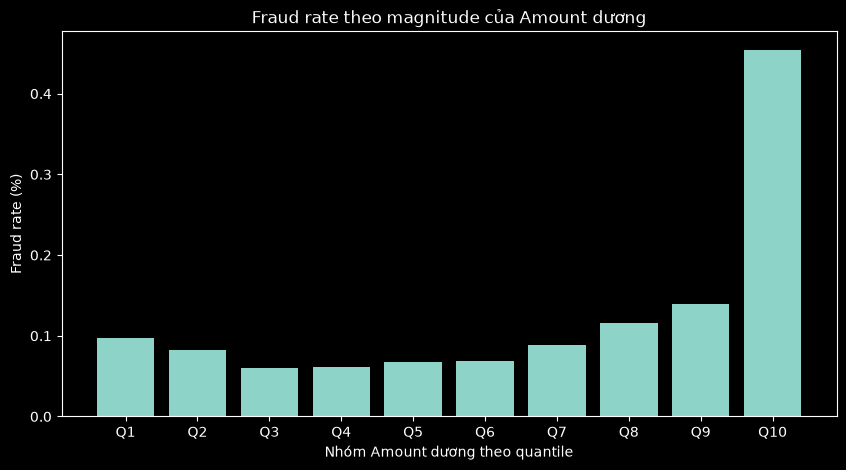

In [13]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    amount_bin_target_df[
        "amount_bin"
    ],
    amount_bin_target_df[
        "fraud_rate_pct"
    ],
)

plt.xlabel(
    "Nhóm Amount dương theo quantile"
)

plt.ylabel(
    "Fraud rate (%)"
)

plt.title(
    "Fraud rate theo magnitude của Amount dương"
)

plt.show()

### Nhận xét M2.6.4

Các quantile bin của Amount dương tạo ra các nhóm có support tương đối đồng đều, khoảng `2.3 triệu transaction/bin`. <br>

Điều này cho phép so sánh fraud rate giữa các mức Amount mà không bị một bin có support quá nhỏ chi phối. <br>

Fraud rate không tăng đơn điệu từ Amount nhỏ nhất tới lớn nhất trong toàn bộ 10 bin. <br>

Ở các bin thấp và trung bình, fraud rate chủ yếu nằm dưới mức fraud rate toàn dataset. <br>

Ví dụ: <br>
`Q3 ≈ 0.0600%` <br>
`Q4 ≈ 0.0619%` <br>
`Q5 ≈ 0.0678%` <br>
`Q6 ≈ 0.0689%`. <br>

Từ các bin cao hơn, fraud rate bắt đầu tăng rõ hơn: <br>
`Q8 ≈ 0.1153%` <br>
`Q9 ≈ 0.1391%`. <br>

Đặc biệt `Q10`, tức nhóm Amount dương cao nhất với boundary bắt đầu khoảng `109.45`, có: <br>
`2,323,641 transaction` <br>
`10,556 fraud` <br>
`fraud rate ≈ 0.4543%` <br>
`lift ≈ 3.72×`. <br>

Riêng Q10 chứa khoảng `35.47% toàn bộ fraud`, dù chỉ chiếm khoảng một phần mười số Amount dương. <br>

Như vậy magnitude của Amount có association rõ với target, đặc biệt ở phần upper tail. <br>

Tuy nhiên pattern không phải một quan hệ tuyến tính đơn giản kiểu `Amount càng lớn thì fraud rate luôn tăng`. <br>

Phần giữa distribution khá phẳng và thấp, trong khi tăng mạnh chủ yếu xuất hiện ở các quantile trên. <br>

Điều này gợi ý rằng nếu Amount được sử dụng trong model, việc giữ information về magnitude có khả năng hữu ích hơn việc chỉ dùng sign. <br>

M2.6 chưa quyết định log-transform, binning hay scaling; các quyết định preprocessing này thuộc M4 và nếu binning được dùng trong model thì boundary phải được học chỉ từ training data. <br>

`Kết luận: Amount magnitude có association phi tuyến với fraud; upper tail, đặc biệt Q10, có fraud rate và fraud contribution cao rõ rệt.`

## M2.6.5 — Quan hệ giữa MCC và target

### Câu hỏi

Fraud có phân bố giống nhau giữa các MCC hay không? <br>

Những MCC có nhiều transaction có đồng thời đóng góp nhiều fraud hay không? <br>

### Nguyên tắc

MCC có long-tail mạnh. <br>

Vì vậy không xếp hạng chính bằng fraud rate, do các MCC support nhỏ có thể cho rate cực đoan chỉ từ vài fraud. <br>

Hai góc nhìn chính được dùng: <br>
- category có `transaction_count` lớn; <br>
- category có `fraud_count` lớn. <br>

Fraud rate luôn được hiển thị kèm support. <br>

In [14]:
mcc_target_df = (
    build_relationship_df(
        mcc_total,
        mcc_fraud,
        "MCC",
    )
)


mcc_preview_n = min(
    CATEGORY_PREVIEW_N,
    len(
        mcc_target_df
    ),
)


print(
    f"{mcc_preview_n} MCC "
    "có nhiều transaction nhất:"
)

display(
    mcc_target_df
    .sort_values(
        "transaction_count",
        ascending=False,
    )
    .head(
        mcc_preview_n
    )
)


print(
    f"\n{mcc_preview_n} MCC "
    "có nhiều fraud nhất:"
)

display(
    mcc_target_df
    .sort_values(
        [
            "fraud_count",
            "transaction_count",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(
        mcc_preview_n
    )
)

15 MCC có nhiều transaction nhất:


,MCC,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,5411,2860738,943,0.032964,0.270148,3.169002
1,5499,2680609,260,0.009699,0.079489,0.873744
2,5541,2638982,354,0.013414,0.109935,1.189636
6,5812,1797920,327,0.018188,0.149054,1.098901
4,5912,1407636,1057,0.075090,0.615392,3.552105
3,4829,1129061,1607,0.142331,1.166449,5.400410
5,4784,1124291,0,0.000000,0.000000,0.000000
8,5300,1123037,2201,0.195986,1.606177,7.396579
7,4121,981523,558,0.056850,0.465909,1.875189
11,7538,914630,51,0.005576,0.045697,0.171388



15 MCC có nhiều fraud nhất:


,MCC,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
9,5311,885720,4824,0.544642,4.463528,16.211312
8,5300,1123037,2201,0.195986,1.606177,7.396579
16,5310,454107,2152,0.473897,3.883752,7.231912
3,4829,1129061,1607,0.142331,1.166449,5.400410
4,5912,1407636,1057,0.075090,0.615392,3.552105
0,5411,2860738,943,0.032964,0.270148,3.169002
23,5815,115247,879,0.762710,6.250672,2.953927
20,5651,137489,849,0.617504,5.060660,2.853110
71,5732,12593,843,6.694195,54.861266,2.832947
22,5719,160277,717,0.447351,3.666194,2.409517


In [15]:
mcc_relationship_summary = pd.Series(
    {
        "unique_mcc":
            len(
                mcc_target_df
            ),

        "mcc_with_at_least_one_fraud":
            int(
                (
                    mcc_target_df[
                        "fraud_count"
                    ]
                    > 0
                ).sum()
            ),

        "mcc_with_zero_fraud":
            int(
                (
                    mcc_target_df[
                        "fraud_count"
                    ]
                    == 0
                ).sum()
            ),

        "max_transaction_count":
            int(
                mcc_target_df[
                    "transaction_count"
                ].max()
            ),

        "min_transaction_count":
            int(
                mcc_target_df[
                    "transaction_count"
                ].min()
            ),
    }
)


display(
    mcc_relationship_summary
)

unique_mcc                         109
mcc_with_at_least_one_fraud         98
mcc_with_zero_fraud                 11
max_transaction_count          2860738
min_transaction_count              496
dtype: int64

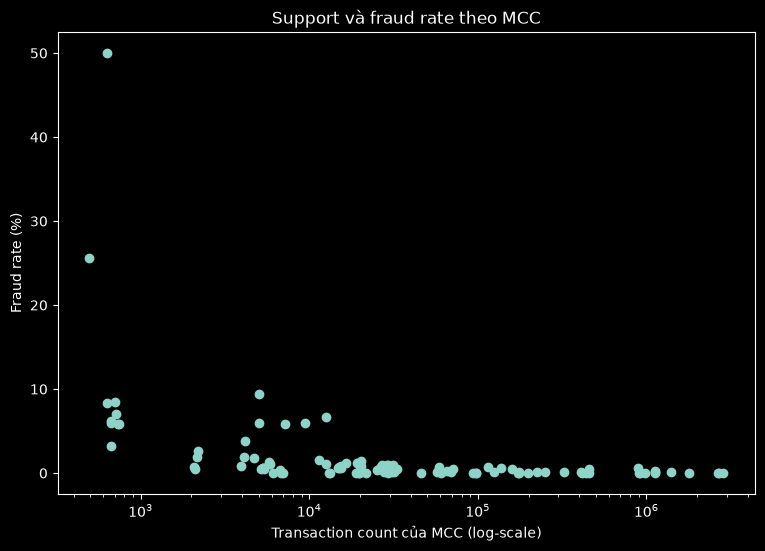

In [16]:
plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    mcc_target_df[
        "transaction_count"
    ],
    mcc_target_df[
        "fraud_rate_pct"
    ],
)

plt.xscale(
    "log"
)

plt.xlabel(
    "Transaction count của MCC (log-scale)"
)

plt.ylabel(
    "Fraud rate (%)"
)

plt.title(
    "Support và fraud rate theo MCC"
)

plt.show()

### Nhận xét M2.6.5

Trong `109 MCC`, có `98 MCC` xuất hiện ít nhất một fraud và `11 MCC` không có fraud trong toàn dataset. <br>

Support giữa các MCC tiếp tục chênh lệch rất lớn: từ `496` tới `2,860,738 transaction`. <br>

Do đó fraud rate theo MCC phải luôn được đọc cùng transaction count. <br>

Một số MCC có support lớn nhưng fraud rate thấp, ví dụ: <br>
`5411: 2,860,738 transaction — fraud rate ≈ 0.0330%` <br>
`5499: 2,680,609 — ≈ 0.0097%` <br>
`5541: 2,638,982 — ≈ 0.0134%`. <br>

Ngược lại, một số MCC có cả support đáng kể và fraud association mạnh. <br>

Ví dụ: <br>
`MCC 5311` <br>
→ `885,720 transaction` <br>
→ `4,824 fraud` <br>
→ `fraud rate ≈ 0.5446%` <br>
→ `lift ≈ 4.46×` <br>
→ đóng góp khoảng `16.21% toàn bộ fraud`. <br>

`MCC 5310` có `454,107 transaction`, fraud rate khoảng `0.4739%` và hơn `2,100 fraud`. <br>

`MCC 5300` có hơn `1.12 triệu transaction` và fraud rate khoảng `0.1960%`. <br>

Đây là các association có support đủ lớn để đáng chú ý hơn những category chỉ có vài chục hoặc vài trăm transaction. <br>

Ngược lại, một số MCC có fraud rate cực cao nhưng support nhỏ hơn nhiều. <br>

Ví dụ: <br>
`MCC 5045: 5,013 transaction — fraud rate ≈ 9.38%` <br>
`MCC 5732: 12,593 transaction — ≈ 6.69%` <br>
`MCC 5094: 9,444 transaction — ≈ 6.00%`. <br>

Các category này đáng ghi nhận nhưng không nên được đặt ngang với các relationship có hàng trăm nghìn hoặc hàng triệu transaction chỉ dựa trên fraud rate. <br>

Một finding khác đáng chú ý là một số MCC có support rất lớn nhưng `0 fraud`, ví dụ MCC `4784` có hơn `1.12 triệu transaction` nhưng không có fraud trong artifact. <br>

Trong synthetic dataset, các pattern gần như loại trừ hoặc tập trung fraud theo category mạnh như vậy có thể phản ánh logic của fraud generator. <br>

Do đó raw MCC có khả năng tạo shortcut mạnh trong model và cần được kiểm tra về temporal/generalization stability trước khi coi association này là ổn định. <br>

15 MCC có nhiều fraud nhất đóng góp phần lớn positive class; riêng ba MCC đứng đầu theo fraud count đã chiếm hơn 30% tổng fraud. <br>

`Kết luận: MCC có association rất mạnh và không đồng đều với target. Một số association có support lớn và đáng chú ý, nhưng long-tail và các category gần deterministic trong synthetic artifact tạo rủi ro shortcut / overfitting; không được lựa chọn MCC chỉ dựa trên fraud rate toàn lịch sử.`

## M2.6.6 — Quan hệ giữa các feature thời gian và target

### Câu hỏi

Fraud rate thay đổi như thế nào theo: <br>
- giờ trong ngày; <br>
- thứ trong tuần; <br>
- tháng trong năm? <br>

Pattern transaction frequency ở M2.4 có tương ứng với pattern fraud hay không? <br>

### Lưu ý

Các bảng này tổng hợp trên toàn bộ 1991–2020. <br>

M2.3 đã xác nhận fraud distribution thay đổi mạnh theo năm, do đó đây chỉ là association tổng thể và có thể chịu ảnh hưởng của temporal regime. <br>

In [17]:
hour_target_df = (
    build_relationship_df(
        hour_total,
        hour_fraud,
        "hour",
    )
    .sort_values(
        "hour"
    )
    .reset_index(drop=True)
)


display(
    hour_target_df
)

,hour,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,0,235608,120,0.050932,0.417406,0.403266
1,1,213411,185,0.086687,0.710432,0.621702
2,2,214075,231,0.107906,0.884328,0.776288
3,3,183370,342,0.186508,1.528499,1.149309
4,4,203550,372,0.182756,1.497750,1.250126
5,5,321588,505,0.157033,1.286942,1.697080
6,6,1347058,855,0.063472,0.520172,2.873274
7,7,1644618,1597,0.097105,0.795806,5.366804
8,8,1616851,1674,0.103535,0.848502,5.625567
9,9,1598928,2178,0.136216,1.116340,7.319286


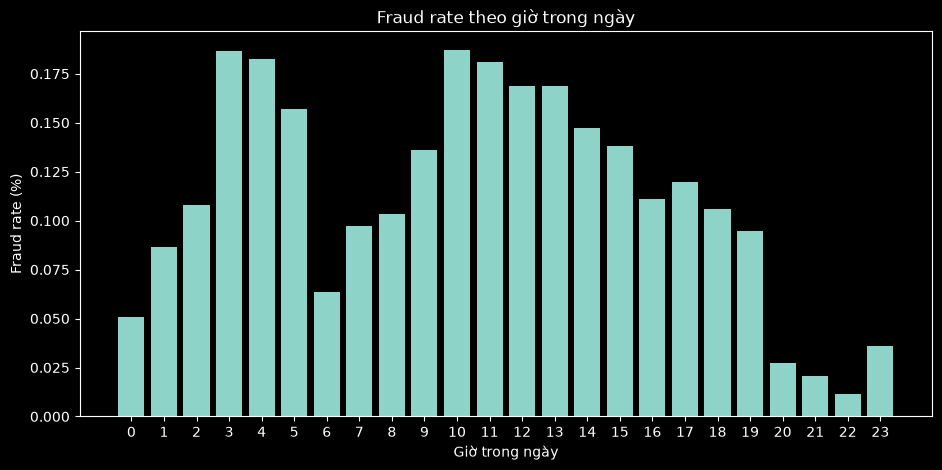

In [18]:
plt.figure(
    figsize=(11, 5)
)

plt.bar(
    hour_target_df[
        "hour"
    ].astype(int),
    hour_target_df[
        "fraud_rate_pct"
    ],
)

plt.xlabel(
    "Giờ trong ngày"
)

plt.ylabel(
    "Fraud rate (%)"
)

plt.title(
    "Fraud rate theo giờ trong ngày"
)

plt.xticks(
    range(24)
)

plt.show()

In [19]:
DAY_NAMES_VI = {
    0: "Thứ Hai",
    1: "Thứ Ba",
    2: "Thứ Tư",
    3: "Thứ Năm",
    4: "Thứ Sáu",
    5: "Thứ Bảy",
    6: "Chủ Nhật",
}


day_target_df = (
    build_relationship_df(
        day_of_week_total,
        day_of_week_fraud,
        "day_of_week",
    )
    .sort_values(
        "day_of_week"
    )
    .reset_index(drop=True)
)


day_target_df[
    "day_name"
] = (
    day_target_df[
        "day_of_week"
    ]
    .astype(int)
    .map(
        DAY_NAMES_VI
    )
)


display(
    day_target_df
)

,day_of_week,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct,day_name
0,0,3480263,3876,0.111371,0.912723,13.025507,Thứ Hai
1,1,3468169,3921,0.113057,0.926540,13.176732,Thứ Ba
2,2,3475771,2911,0.083751,0.686370,9.782572,Thứ Tư
3,3,3495004,5220,0.149356,1.224025,17.542091,Thứ Năm
4,4,3482897,4908,0.140917,1.154865,16.493598,Thứ Sáu
5,5,3499591,3506,0.100183,0.821036,11.782102,Thứ Bảy
6,6,3485205,5415,0.155371,1.273320,18.197399,Chủ Nhật


In [20]:
month_target_df = (
    build_relationship_df(
        month_total,
        month_fraud,
        "Month",
    )
    .sort_values(
        "Month"
    )
    .reset_index(drop=True)
)


display(
    month_target_df
)

,Month,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,1,2142220,2302,0.107459,0.880661,7.735995
1,2,1960411,2320,0.118343,0.969858,7.796485
2,3,2002867,2608,0.130213,1.067144,8.764324
3,4,1941806,2430,0.125141,1.025576,8.166146
4,5,2023412,2481,0.122615,1.004870,8.337534
5,6,1981230,2166,0.109326,0.895965,7.278960
6,7,2051785,2332,0.113657,0.931460,7.836812
7,8,2070407,2721,0.131423,1.077061,9.144067
8,9,2006307,2373,0.118277,0.969321,7.974594
9,10,2075188,2666,0.128470,1.052859,8.959236


### Nhận xét M2.6.6

Quan hệ giữa `hour_of_day` và fraud rõ hơn đáng kể so với transaction-frequency pattern đơn thuần ở M2.4. <br>

Fraud rate thay đổi mạnh theo giờ. <br>

Một số giờ có fraud rate tương đối cao: <br>
`03:00 ≈ 0.1865%` <br>
`04:00 ≈ 0.1828%` <br>
`10:00 ≈ 0.1872%` <br>
`11:00 ≈ 0.1812%`. <br>

Trong khi đó, các giờ cuối buổi tối có fraud rate rất thấp: <br>
`20:00 ≈ 0.0272%` <br>
`21:00 ≈ 0.0205%` <br>
`22:00 ≈ 0.0116%` <br>
`23:00 ≈ 0.0359%`. <br>

Như vậy `hour_of_day` có association rõ với target trên full dataset và không chỉ phản ánh lượng transaction trong từng giờ. <br>

Đối với `day_of_week`, khác biệt tồn tại nhưng yếu hơn. <br>

Fraud rate thấp nhất nằm ở `Thứ Tư ≈ 0.0838%`, trong khi cao nhất ở `Chủ Nhật ≈ 0.1554%`. <br>

Tỷ lệ cao nhất xấp xỉ 1.85 lần thấp nhất. <br>

Do transaction count giữa các ngày gần như cân bằng, chênh lệch này không đơn giản được giải thích bởi support khác nhau. <br>

Đối với `Month`, fraud rate chỉ dao động trong khoảng tương đối hẹp, khoảng `0.107%–0.131%`. <br>

Association theo tháng yếu hơn đáng kể so với hour_of_day. <br>

Tuy nhiên tất cả các bảng trên đều tổng hợp xuyên suốt gần 30 năm dữ liệu. <br>

M2.3 đã chứng minh fraud prevalence thay đổi rất mạnh giữa các temporal regime, vì vậy không được xem những pattern giờ / ngày / tháng này là ổn định theo thời gian nếu chưa có kiểm tra bổ sung. <br>

`Kết luận: hour_of_day có association tương đối mạnh với target trên full dataset; day_of_week có association mức vừa; month chỉ cho chênh lệch nhỏ hơn. Temporal drift vẫn là yếu tố gây nhiễu quan trọng khi diễn giải.`

## M2.6.7 — Quan hệ giữa location và target

### Câu hỏi

Fraud rate khác nhau thế nào giữa các representation location? <br>

Sự khác biệt của location missing có còn tồn tại khi đặt trong context của transaction mode hay không? <br>

Các raw location category có biểu hiện association đáng chú ý nào cần tiếp tục xem xét không? <br>

### Nguyên tắc

M2.5 đã chứng minh missing location mang tính structural. <br>

Do đó: <br>
`missing ↔ fraud` không được diễn giải như một quan hệ độc lập. <br>

Phân tích chính sử dụng: <br>
`location_status × Use Chip ↔ target`. <br>

In [21]:
location_status_target_df = (
    build_relationship_df(
        location_status_total,
        location_status_fraud,
        "location_status",
    )
    .sort_values(
        "transaction_count",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(
    location_status_target_df
)

,location_status,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,STATE_ZIP_PRESENT,21508765,4905,0.022805,0.186892,16.483516
1,CITY_ONLINE_STATE_ZIP_MISSING,2720821,18349,0.674392,5.526878,61.662802
2,STATE_PRESENT_ZIP_MISSING,157314,6503,4.133771,33.877693,21.853681


In [22]:
location_mode_target_df = (
    build_multi_relationship_df(
        location_mode_total,
        location_mode_fraud,
        [
            "Use Chip",
            "location_status",
        ],
    )
    .sort_values(
        [
            "Use Chip",
            "transaction_count",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


display(
    location_mode_target_df
)

,Use Chip,location_status,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,Chip Transaction,STATE_ZIP_PRESENT,6228476,593,0.009521,0.078026,1.992808
1,Chip Transaction,STATE_PRESENT_ZIP_MISSING,51521,4243,8.235477,67.492606,14.258830
2,Chip Transaction,CITY_ONLINE_STATE_ZIP_MISSING,7601,0,0.000000,0.000000,0.000000
3,Online Transaction,CITY_ONLINE_STATE_ZIP_MISSING,2713220,18349,0.676281,5.542361,61.662802
4,Swipe Transaction,STATE_ZIP_PRESENT,15280289,4312,0.028219,0.231268,14.490708
5,Swipe Transaction,STATE_PRESENT_ZIP_MISSING,105793,2260,2.136247,17.507291,7.594852


In [23]:
city_target_df = (
    build_relationship_df(
        city_total,
        city_fraud,
        "Merchant City",
    )
)

state_target_df = (
    build_relationship_df(
        state_total,
        state_fraud,
        "Merchant State",
    )
)

zip_target_df = (
    build_relationship_df(
        zip_total,
        zip_fraud,
        "Zip",
    )
)

In [24]:
def display_category_views(
    df,
    feature_name,
    preview_n=CATEGORY_PREVIEW_N,
):
    n = min(
        preview_n,
        len(df),
    )

    print(
        f"{n} {feature_name} "
        "có nhiều transaction nhất:"
    )

    display(
        df
        .sort_values(
            "transaction_count",
            ascending=False,
        )
        .head(n)
    )

    print(
        f"\n{n} {feature_name} "
        "có nhiều fraud nhất:"
    )

    display(
        df
        .sort_values(
            [
                "fraud_count",
                "transaction_count",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .head(n)
    )

In [25]:
display_category_views(
    state_target_df,
    "Merchant State",
)

display_category_views(
    city_target_df,
    "Merchant City",
)

display_category_views(
    zip_target_df,
    "Zip",
)

15 Merchant State có nhiều transaction nhất:


,Merchant State,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
1,<MISSING>,2720821,18349,0.674392,5.526878,61.662802
0,CA,2591830,751,0.028976,0.237466,2.523776
4,TX,1793298,305,0.017008,0.139385,1.024969
12,FL,1458699,314,0.021526,0.176413,1.055214
10,NY,1446864,240,0.016588,0.135941,0.806533
11,OH,895970,878,0.097994,0.803098,2.950566
18,IL,850074,114,0.013411,0.109905,0.383103
9,PA,839647,144,0.017150,0.140551,0.483920
19,NC,779234,144,0.018480,0.151447,0.483920
23,GA,638884,100,0.015652,0.128276,0.336055



15 Merchant State có nhiều fraud nhất:


,Merchant State,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
1,<MISSING>,2720821,18349,0.674392,5.526878,61.662802
38,Italy,8730,4682,53.631157,439.526048,15.734113
11,OH,895970,878,0.097994,0.803098,2.950566
0,CA,2591830,751,0.028976,0.237466,2.523776
97,Algeria,654,629,96.177370,788.207113,2.113788
102,Haiti,446,375,84.080717,689.070823,1.260208
12,FL,1458699,314,0.021526,0.176413,1.055214
4,TX,1793298,305,0.017008,0.139385,1.024969
27,Mexico,47152,272,0.576858,4.727551,0.914071
115,Turkey,472,257,54.449153,446.229807,0.863662


15 Merchant City có nhiều transaction nhất:


...

,Merchant City,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,ONLINE,2720821,18349,0.674392,5.526878,61.662802
102,Rome,13765,4683,34.021068,278.814525,15.737474
920,Algiers,654,629,96.177370,788.207113,2.113788
1971,Port au Prince,446,375,84.080717,689.070823,1.260208
1719,Strasburg,1852,322,17.386609,142.489329,1.082098
124,Mexico City,8878,272,3.063753,25.108526,0.914071
3622,Istanbul,472,257,54.449153,446.229807,0.863662
1051,Abuja,233,143,61.373391,502.976355,0.480559
399,Berkeley,4685,81,1.728922,14.169120,0.272205
2062,Bellevue,3732,59,1.580922,12.956206,0.198273


15 Zip có nhiều transaction nhất:


,Zip,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,<MISSING>,2878135,24852,0.863476,7.076486,83.516484
8683,98516,55679,1,0.001796,0.014719,0.003361
19121,43830,48815,0,0.000000,0.000000,0.000000
7063,55024,44571,1,0.002244,0.018387,0.003361
4015,95076,43656,0,0.000000,0.000000,0.000000
88,94606,43512,45,0.103420,0.847561,0.151225
426,94131,42433,1,0.002357,0.019314,0.003361
12078,87121,42237,0,0.000000,0.000000,0.000000
9766,75023,41953,0,0.000000,0.000000,0.000000
7734,95687,40078,1,0.002495,0.020448,0.003361



15 Zip có nhiều fraud nhất:


,Zip,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,<MISSING>,2878135,24852,0.863476,7.076486,83.516484
2595,44680,889,320,35.995501,294.995689,1.075377
14072,44807,73,58,79.452055,651.137317,0.194912
5642,44811,147,56,38.095238,312.203771,0.188191
1753,44820,291,48,16.494845,135.181014,0.161307
88,94606,43512,45,0.103420,0.847561,0.151225
8383,94702,476,40,8.403361,68.868479,0.134422
10751,44681,957,38,3.970742,32.541616,0.127701
14714,44824,1003,25,2.492522,20.427091,0.084014
8454,45014,13631,22,0.161397,1.322703,0.073932


### Nhận xét M2.6.7

Location representation có association rất mạnh với target. <br>

Ở cấp semantic location status: <br>

`STATE_ZIP_PRESENT` <br>
→ `21,508,765 transaction` <br>
→ `4,905 fraud` <br>
→ `fraud rate ≈ 0.0228%` <br>
→ chỉ khoảng `0.19×` fraud rate toàn dataset. <br>

`CITY_ONLINE_STATE_ZIP_MISSING` <br>
→ `2,720,821 transaction` <br>
→ `18,349 fraud` <br>
→ `fraud rate ≈ 0.6744%` <br>
→ `lift ≈ 5.53×`. <br>

`STATE_PRESENT_ZIP_MISSING` <br>
→ chỉ `157,314 transaction` <br>
→ nhưng có `6,503 fraud` <br>
→ `fraud rate ≈ 4.13%` <br>
→ `lift ≈ 33.88×`. <br>

Như vậy nhóm State present nhưng Zip missing chỉ chiếm một phần nhỏ dataset nhưng chứa khoảng `21.85% toàn bộ fraud`. <br>

Kết hợp finding của M2.5, nhóm này chủ yếu đại diện cho non-online / international merchant location, không đơn giản là một lỗi thiếu Zip ngẫu nhiên. <br>

Khi stratify thêm theo transaction mode, association vẫn tồn tại rất mạnh: <br>

`Chip + STATE_PRESENT_ZIP_MISSING` <br>
→ `51,521 transaction` <br>
→ `4,243 fraud` <br>
→ `fraud rate ≈ 8.24%` <br>
→ `lift ≈ 67.5×`. <br>

`Swipe + STATE_PRESENT_ZIP_MISSING` <br>
→ `105,793 transaction` <br>
→ `2,260 fraud` <br>
→ `fraud rate ≈ 2.14%` <br>
→ `lift ≈ 17.5×`. <br>

Do đó association của `STATE_PRESENT_ZIP_MISSING` không thể được giải thích hoàn toàn chỉ bằng Use Chip. <br>

Một pattern khác là nhóm `Chip + City=ONLINE + State/Zip missing` gồm `7,601 transaction` nhưng `0 fraud`, trong khi Online Transaction cùng location status có fraud rate khoảng `0.676%`. <br>

Điều này tiếp tục cho thấy transaction mode và semantic location phải được xét cùng nhau. <br>

Ở raw location category, xuất hiện nhiều association cực mạnh. <br>

Ví dụ: <br>
`Merchant State = Italy`: `8,730 transaction`, fraud rate khoảng `53.63%`; <br>
`Merchant State = Algeria`: `654 transaction`, fraud rate khoảng `96.18%`; <br>
`Merchant City = Rome`: `13,765 transaction`, fraud rate khoảng `34.02%`; <br>
`Merchant City = Algiers`: `654 transaction`, fraud rate khoảng `96.18%`. <br>

Một số category có fraud rate gần hoặc bằng 100%, nhưng support của nhiều category khá nhỏ. <br>

Ví dụ `Funafuti = 59 / 59 fraud`; con số 100% này không được xem là bằng chứng mạnh chỉ vì rate cực đoan. <br>

Tuy nhiên một số location như Rome/Italy có hàng nghìn transaction và hàng nghìn fraud, nên association không thể bị bỏ qua như noise support nhỏ. <br>

Ở Zip level cũng tồn tại những fraud rate cực cao trong các Zip support thấp hoặc vừa. <br>

Đặc biệt, `<MISSING>` Zip chứa `24,852 fraud`, tương đương khoảng `83.5% toàn bộ fraud`, nhưng M2.5 đã chứng minh Zip missing trộn nhiều semantic mechanism khác nhau. <br>

Do đó không được diễn giải `Zip missing` như một causal fraud signal độc lập. <br>

Các raw location association rất mạnh có nguy cơ hoạt động như proxy cho merchant identity hoặc logic của synthetic fraud generator. <br>

Chúng có thể hữu ích trong artifact này nhưng cũng tạo rủi ro shortcut, high-cardinality overfitting và generalization kém nếu distribution thay đổi. <br>

`Kết luận: location chứa association cực mạnh với target, đặc biệt ở nhóm State-present/Zip-missing và một số international location. Association vẫn tồn tại sau khi stratify theo transaction mode, nhưng mức cực đoan của nhiều raw location category tạo rủi ro synthetic shortcut; chưa có cơ sở để tự động giữ toàn bộ City/State/Zip làm feature trực tiếp.`

## M2.6.8 — Kiểm tra độ ổn định của association theo thời gian

### Vì sao kiểm tra này tồn tại?

M2.3 đã phát hiện một điểm gãy temporal regime khoảng `11/2019`. <br>

Vì vậy các association tổng thể ở M2.6 có thể bị chi phối bởi việc feature distribution và fraud prevalence cùng thay đổi theo thời gian. <br>

### Câu hỏi

Các quan hệ chính có còn giống nhau trong những giai đoạn gần cuối dataset hay không? <br>

Các giai đoạn được kiểm tra: <br>
`2018` <br>
`2019-01 → 2019-10` <br>
`2019-11 → 2019-12` <br>
`2020-01 → 2020-02` <br>

Các period này được chọn dựa trên finding M2.3, không phải chọn ngẫu nhiên. <br>

### Phạm vi

Tập trung vào hai relationship dễ diễn giải và đã có finding rõ: <br>
`Use Chip ↔ target` <br>
`Amount sign × Use Chip ↔ target` <br>

In [26]:
period_use_chip_target_df = (
    build_multi_relationship_df(
        period_use_chip_total,
        period_use_chip_fraud,
        [
            "period",
            "Use Chip",
        ],
    )
    .sort_values(
        [
            "period",
            "Use Chip",
        ]
    )
    .reset_index(drop=True)
)


display(
    period_use_chip_target_df
)

,period,Use Chip,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,2018,Chip Transaction,1215055,2113,0.173902,1.425184,7.100850
1,2018,Online Transaction,213632,128,0.059916,0.491033,0.430151
2,2018,Swipe Transaction,292928,250,0.085345,0.699434,0.840138
3,2019-01_to_10,Chip Transaction,1014280,1895,0.186832,1.531154,6.368249
4,2019-01_to_10,Online Transaction,177986,0,0.000000,0.000000,0.000000
5,2019-01_to_10,Swipe Transaction,243147,192,0.078965,0.647142,0.645226
6,2019-11_to_12,Chip Transaction,203328,0,0.000000,0.000000,0.000000
7,2019-11_to_12,Online Transaction,35967,0,0.000000,0.000000,0.000000
8,2019-11_to_12,Swipe Transaction,49230,0,0.000000,0.000000,0.000000
9,2020-01_to_02,Chip Transaction,235863,0,0.000000,0.000000,0.000000


In [27]:
period_amount_mode_target_df = (
    build_multi_relationship_df(
        period_amount_mode_total,
        period_amount_mode_fraud,
        [
            "period",
            "Use Chip",
            "amount_sign",
        ],
    )
    .sort_values(
        [
            "period",
            "Use Chip",
            "amount_sign",
        ]
    )
    .reset_index(drop=True)
)


display(
    period_amount_mode_target_df
)

,period,Use Chip,amount_sign,transaction_count,fraud_count,fraud_rate_pct,lift_vs_overall,fraud_share_pct
0,2018,Chip Transaction,negative,65528,45,0.068673,0.562799,0.151225
1,2018,Chip Transaction,positive,1148422,2065,0.179812,1.473622,6.939544
2,2018,Chip Transaction,zero,1105,3,0.271493,2.224982,0.010082
3,2018,Online Transaction,negative,457,7,1.531729,12.553051,0.023524
4,2018,Online Transaction,positive,213175,121,0.056761,0.465175,0.406627
5,2018,Swipe Transaction,negative,16329,19,0.116357,0.953590,0.063851
6,2018,Swipe Transaction,positive,276340,231,0.083593,0.685071,0.776288
7,2018,Swipe Transaction,zero,259,0,0.000000,0.000000,0.000000
8,2019-01_to_10,Chip Transaction,negative,55406,35,0.063170,0.517701,0.117619
9,2019-01_to_10,Chip Transaction,positive,957987,1857,0.193844,1.588619,6.240548


### Nhận xét M2.6.8

Kết quả temporal stratification cho thấy nhiều association rất mạnh trên full dataset `không ổn định theo thời gian`. <br>

Trên toàn bộ 1991–2020, Online Transaction có fraud rate cao nhất trong ba mode, khoảng `0.676%`. <br>

Tuy nhiên ở năm `2018`: <br>
`Chip ≈ 0.174%` <br>
`Swipe ≈ 0.085%` <br>
`Online ≈ 0.060%`. <br>

Như vậy trong 2018, Chip mới là mode có fraud rate cao nhất và Online thấp hơn cả Swipe. <br>

Ở giai đoạn `2019-01 → 2019-10`: <br>
`Chip ≈ 0.187%` <br>
`Swipe ≈ 0.079%` <br>
`Online = 0%`. <br>

Tức association `Online ↔ fraud` nhìn trên full history không chỉ yếu đi mà còn biến mất hoàn toàn trong giai đoạn gần cuối 2019. <br>

Từ `2019-11 → 2020-02`, tất cả transaction mode đều có fraud rate bằng 0 do temporal regime shift đã được M2.3 phát hiện. <br>

Điều này chứng minh rằng ranking risk giữa transaction modes không ổn định qua thời gian. <br>

Finding tương tự xuất hiện với `Negative + Online`. <br>

Trên toàn dataset: <br>
`Negative + Online fraud rate ≈ 6.64%`. <br>

Nhưng ở `2018`: <br>
`457 transaction` <br>
`7 fraud` <br>
`fraud rate ≈ 1.53%`. <br>

Ở `2019-01 → 2019-10`: <br>
`337 transaction` <br>
`0 fraud`. <br>

Như vậy relationship rất mạnh khi tổng hợp toàn lịch sử đã suy yếu đáng kể trong 2018 và biến mất ở 2019 trước cả breakpoint zero-fraud cuối năm. <br>

Trong khi đó, positive Chip vẫn duy trì fraud rate khoảng `0.180%` ở 2018 và `0.194%` trong 10 tháng đầu 2019. <br>

Đây là ví dụ trực tiếp cho failure mode: <br>
`association mạnh trên full dataset ≠ association ổn định cho future data`. <br>

Do đó các fraud-rate association tính trên toàn bộ lịch sử không nên được dùng để lựa chọn feature hoặc thiết kế rule mà không có temporal validation. <br>

Kết quả này củng cố mạnh yêu cầu dùng temporal split và cho thấy lựa chọn training window có thể ảnh hưởng lớn tới những pattern model học được. <br>

`Kết luận: temporal instability của feature-target relationship đã được xác nhận. Use Chip và Negative×Online đều có association full-history mạnh nhưng thay đổi hoặc biến mất ở giai đoạn gần cuối dataset. Đây là bằng chứng trực tiếp chống lại random split và full-history feature interpretation không có temporal validation.`

## M2.6.9 — Đối chiếu một số relationship với Milestone 1

### Câu hỏi

Các relationship được tính độc lập trong M2.6 có nhất quán với Risk Audit của M1 hay không? <br>

### Các mốc đối chiếu

M1 đã ghi nhận: <br>
- tổng fraud = `29,757`; <br>
- negative Amount = `1,244,683 transaction`; <br>
- fraud trong negative Amount = `1,125`; <br>
- zero Amount = `20,213`; <br>
- fraud trong zero Amount = `13`; <br>
- Negative + Online = `13,499 transaction`; <br>
- fraud trong Negative + Online = `896`. <br>

M1 chỉ được dùng làm cross-check sau khi M2.6 đã tự tính kết quả. <br>

In [28]:
negative_row = (
    amount_sign_target_df
    .loc[
        amount_sign_target_df[
            "amount_sign"
        ]
        == "negative"
    ]
    .iloc[0]
)


zero_row = (
    amount_sign_target_df
    .loc[
        amount_sign_target_df[
            "amount_sign"
        ]
        == "zero"
    ]
    .iloc[0]
)


negative_online_row = (
    amount_sign_mode_target_df
    .loc[
        (
            amount_sign_mode_target_df[
                "Use Chip"
            ]
            == "Online Transaction"
        )
        &
        (
            amount_sign_mode_target_df[
                "amount_sign"
            ]
            == "negative"
        )
    ]
    .iloc[0]
)


m26_consistency_checks = pd.Series(
    {
        "Tổng transaction = 24,386,900":
            total_rows
            == 24_386_900,

        "Fraud = 29,757":
            total_fraud
            == 29_757,

        "Target missing = 0":
            missing_target_count
            == 0,

        "Negative Amount rows = 1,244,683":
            int(
                negative_row[
                    "transaction_count"
                ]
            )
            == 1_244_683,

        "Negative Amount fraud = 1,125":
            int(
                negative_row[
                    "fraud_count"
                ]
            )
            == 1_125,

        "Zero Amount rows = 20,213":
            int(
                zero_row[
                    "transaction_count"
                ]
            )
            == 20_213,

        "Zero Amount fraud = 13":
            int(
                zero_row[
                    "fraud_count"
                ]
            )
            == 13,

        "Negative Online rows = 13,499":
            int(
                negative_online_row[
                    "transaction_count"
                ]
            )
            == 13_499,

        "Negative Online fraud = 896":
            int(
                negative_online_row[
                    "fraud_count"
                ]
            )
            == 896,
    }
)


display(
    m26_consistency_checks
)


print(
    "Tất cả phép đối chiếu đều khớp:",
    m26_consistency_checks.all(),
)

Tổng transaction = 24,386,900       True
Fraud = 29,757                      True
Target missing = 0                  True
Negative Amount rows = 1,244,683    True
Negative Amount fraud = 1,125       True
Zero Amount rows = 20,213           True
Zero Amount fraud = 13              True
Negative Online rows = 13,499       True
Negative Online fraud = 896         True
dtype: bool

Tất cả phép đối chiếu đều khớp: True


### Nhận xét M2.6.9

Tất cả các phép đối chiếu với những relationship đã được Risk Audit ở M1 đều trả về `True`. <br>

M2.6 xác nhận độc lập: <br>
`Tổng transaction = 24,386,900` <br>
`Fraud = 29,757` <br>
`Target missing = 0` <br>
`Negative Amount rows = 1,244,683` <br>
`Negative Amount fraud = 1,125` <br>
`Zero Amount rows = 20,213` <br>
`Zero Amount fraud = 13` <br>
`Negative + Online rows = 13,499` <br>
`Negative + Online fraud = 896` <br>

Không phát hiện bất nhất giữa feature-target audit ở M2.6 và Risk Audit của M1. <br>

Quan trọng hơn, M2.6 bổ sung thông tin mà M1 chưa đủ để kết luận: relationship Negative + Online tuy mạnh trên full dataset nhưng không ổn định qua temporal regime. <br>

`Kết luận: PASS`

# Tổng kết M2.6 — Phân tích mối quan hệ giữa feature và target

## Các phát hiện chính

M2.6 xác nhận nhiều feature có association rõ với target trên toàn dataset. <br>

Các association mạnh xuất hiện ở: <br>
- transaction mode; <br>
- upper tail của Amount; <br>
- một số MCC; <br>
- hour_of_day; <br>
- semantic location status; <br>
- một số raw location category. <br>

Tuy nhiên M2.6 cũng xác nhận một finding quan trọng hơn: <br>
`feature-target association không ổn định theo thời gian`. <br>

Một số relationship rất mạnh trên full history suy yếu, đảo thứ tự hoặc biến mất hoàn toàn ở các giai đoạn gần cuối dataset. <br>

Do đó không được sử dụng full-dataset fraud rate như bằng chứng duy nhất để chọn feature cho mô hình dự đoán tương lai. <br>

## Kết luận về Use Chip ↔ target

Trên full dataset, Online Transaction có fraud rate khoảng `0.676%`, cao hơn Chip và Swipe nhiều lần và chứa khoảng `61.66% toàn bộ fraud`. <br>

Tuy nhiên relationship này không ổn định. <br>

Trong 2018, Chip có fraud rate cao hơn Online; trong 10 tháng đầu 2019, Online không có fraud trong khi Chip tiếp tục có fraud rate khoảng `0.187%`. <br>

Vì vậy Use Chip có association với target nhưng ý nghĩa của từng category thay đổi theo temporal regime. <br>

`Use Chip` vẫn là candidate feature hợp lý, nhưng phải được đánh giá bằng temporal validation thay vì dựa trên full-history statistics. <br>

## Kết luận về Amount ↔ target

Amount sign đơn lẻ không tạo association mạnh theo hướng negative Amount nguy hiểm hơn. <br>

Positive Amount thậm chí có fraud rate cao hơn negative và zero khi aggregate toàn dataset. <br>

Ngược lại, magnitude của Amount dương cho thấy association rõ ở upper tail. <br>

Nhóm Q10 có fraud rate khoảng `0.454%`, lift khoảng `3.72×` và chứa khoảng `35.47% toàn bộ fraud`. <br>

Do đó information về magnitude của Amount có giá trị EDA rõ hơn sign đơn thuần. <br>

## Kết luận về Amount sign × Use Chip ↔ target

Interaction giữa Amount sign và transaction mode rất mạnh trên full history. <br>

`Negative + Online` có fraud rate khoảng `6.64%`, cao hơn mức chung khoảng `54×`. <br>

Tuy nhiên relationship này giảm còn khoảng `1.53%` trong 2018 và bằng 0 trong 10 tháng đầu 2019. <br>

Vì vậy đây là một association mạnh nhưng không ổn định theo thời gian. <br>

Nhóm `Zero + Online` có fraud rate cực cao nhưng chỉ gồm 9 transaction, nên không được coi là finding đáng tin ở mức population rule. <br>

## Kết luận về MCC ↔ target

MCC có association rất không đồng đều với target. <br>

Một số MCC có support lớn và fraud contribution cao, ví dụ MCC 5311 chứa hơn `4,800 fraud` và khoảng `16.2% toàn bộ fraud`. <br>

Một số MCC support tương đối lớn lại không có fraud trong toàn artifact. <br>

Một số MCC support nhỏ hơn có fraud rate rất cao. <br>

Điều này cho thấy MCC có predictive association tiềm năng nhưng đồng thời tạo rủi ro shortcut trong synthetic dataset. <br>

Không được lựa chọn MCC dựa trên fraud rate đơn độc; support và temporal stability phải được xem cùng nhau. <br>

## Kết luận về các feature thời gian ↔ target

`hour_of_day` thể hiện association rõ với target trên full history, với fraud rate thay đổi mạnh giữa các giờ. <br>

`day_of_week` có association mức vừa, còn `month` có khác biệt nhỏ hơn. <br>

Tuy nhiên các feature thời gian aggregate trên toàn bộ 30 năm có thể trộn nhiều temporal regime khác nhau. <br>

Do đó đây là candidate feature chứ chưa phải bằng chứng về pattern ổn định trong future data. <br>

## Kết luận về location ↔ target

Location tạo ra một số association mạnh nhất trong toàn bộ M2.6. <br>

Nhóm `STATE_PRESENT_ZIP_MISSING` có fraud rate khoảng `4.13%` và chứa khoảng `21.85% toàn bộ fraud` dù chỉ có khoảng 157 nghìn transaction. <br>

Sau khi stratify theo mode, association vẫn rất mạnh: Chip trong nhóm này có fraud rate khoảng `8.24%`, Swipe khoảng `2.14%`. <br>

Một số international location có fraud rate cực cao và support không hoàn toàn nhỏ. <br>

Điều này cho thấy location có khả năng chứa tín hiệu mạnh trong synthetic artifact. <br>

Tuy nhiên raw City/State/Zip có cardinality cao và có thể đóng vai trò proxy cho merchant identity hoặc fraud-generation mechanism. <br>

Do đó chúng có rủi ro overfitting, memorization và synthetic shortcut cao hơn những feature transaction tổng quát. <br>

Chưa có cơ sở để giữ toàn bộ raw location category làm direct model features chỉ từ kết quả M2.6. <br>

## Kết luận về structural missingness ↔ target

Location missing có association rất mạnh với fraud, nhưng M2.5 đã chứng minh missingness mang semantic structure. <br>

`State/Zip missing` không phải một biến độc lập ngẫu nhiên mà gắn với Online Transaction hoặc international merchant pattern. <br>

Do đó fraud association của missing indicator không được diễn giải là “missing gây fraud”. <br>

Nếu missing indicator được sử dụng sau này, phải xem xét redundancy với Use Chip và Merchant City / location status. <br>

## Kết luận về độ ổn định của association theo thời gian

Temporal instability được xác nhận trực tiếp. <br>

Các relationship mạnh như `Online ↔ fraud` và `Negative + Online ↔ fraud` thay đổi đáng kể giữa full history, 2018 và 2019. <br>

Đặc biệt Online Transaction chuyển từ nhóm fraud rate rất cao trên full dataset thành nhóm fraud rate thấp ở 2018 và 0 fraud trong 10 tháng đầu 2019. <br>

Do đó full-history association không thể được xem là proxy đáng tin cho future association. <br>

Đây là một bằng chứng mạnh ủng hộ temporal split, temporal validation và việc xem xét training window thay vì random split. <br>

## Các relationship có dấu hiệu mạnh nhưng cần cảnh giác

Các relationship sau đáng chú ý nhưng không được biến trực tiếp thành rule hoặc feature-selection decision: <br>
`Online Transaction ↔ fraud` <br>
`Negative + Online ↔ fraud` <br>
`Amount upper tail ↔ fraud` <br>
`một số MCC ↔ fraud` <br>
`State-present / Zip-missing ↔ fraud` <br>
`một số international City / State / Zip ↔ fraud` <br>

Lý do cần cảnh giác gồm: <br>
- temporal instability; <br>
- support không đồng đều; <br>
- high-cardinality category; <br>
- interaction giữa nhiều feature; <br>
- synthetic generator bias; <br>
- khả năng tạo shortcut hoặc proxy cho merchant identity. <br>

## Các vấn đề cần chuyển sang M3

M3 phải sử dụng `temporal split` làm evaluation chính. <br>

Feature usefulness không nên được đánh giá bằng random split trên toàn lịch sử. <br>

M3 cần thiết kế validation window để kiểm tra feature association và model performance trên giai đoạn tương lai. <br>

Việc chọn training window phải cân nhắc temporal regime shift đã phát hiện ở M2.3 và M2.6. <br>

Các metric phải phù hợp với class imbalance và không sử dụng Accuracy đơn độc. <br>

Final test phải chứa đủ positive class; 2020 tiếp tục không phù hợp làm final fraud test. <br>

## Các vấn đề cần chuyển sang M4

M4 cần quyết định representation của Amount nhưng phải giữ nguyên dấu cho tới khi có quyết định có căn cứ. <br>

Nếu dùng transformation hoặc binning Amount, mọi parameter / boundary phải được fit chỉ từ training data. <br>

M4 cần quyết định encoding cho MCC và location với lưu ý về long-tail, high cardinality và shortcut risk. <br>

Không nên mặc định one-hot encode toàn bộ Merchant City hoặc Zip chỉ vì chúng có fraud association mạnh. <br>

Missing-location representation phải cân nhắc redundancy giữa `Use Chip`, `Merchant City = ONLINE`, State missing và Zip missing. <br>

## Các limitation còn mở

Temporal stability mới được kiểm tra trực tiếp cho `Use Chip` và `Amount sign × Use Chip`. <br>

MCC và location có association rất mạnh nhưng chưa được audit chi tiết theo nhiều temporal window trong M2.6. <br>

Việc kiểm tra độ ổn định của các association này nên được tiếp tục khi so sánh temporal training windows ở M2.8 / M3. <br>

Các extreme fraud rate của raw location / MCC có thể phản ánh synthetic fraud-generation mechanism; chưa có cơ sở để xem chúng là behavior có thể generalize sang banking data thực tế. <br>

M2.6 chỉ xác nhận association, không chứng minh causation. <br>

## Quyết định M2.6

`Decision ID: M2.6-D01` <br>
`Full-scan feature-target audit: PASS` <br>
`Use Chip association: CONFIRMED BUT TEMPORALLY UNSTABLE` <br>
`Amount magnitude association: CONFIRMED` <br>
`Amount sign × Use Chip interaction: CONFIRMED BUT TEMPORALLY UNSTABLE` <br>
`MCC association: CONFIRMED WITH SHORTCUT RISK` <br>
`Temporal-feature association: CONFIRMED WITH DRIFT CAUTION` <br>
`Location association: STRONG WITH HIGH-CARDINALITY / SHORTCUT RISK` <br>
`Structural missingness association: CONFIRMED, NOT INDEPENDENT` <br>
`Temporal instability of feature-target relationships: CONFIRMED` <br>
`Consistency with M1: PASS` <br>
`Blocking issue: NONE` <br>
`Status: PASS WITH FINDINGS` <br>

## Bước tiếp theo

`Next: M2.7 — Phân tích entity và lịch sử User / Card`